In [1]:
import importlib
from tqdm.auto import tqdm
import os
import pickle

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import torch
import transformers
from transformers import AutoTokenizer, AutoModel
import numpy as np 
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd

from safetensors.torch import load_model
from model import GenderChunkedClassifier

from viz_utils import plot_error_bar, plot_violins
from inference_utils import infer, load_generated_output, find_threshold_for_N, calculate_metrics

/disk/10tb/home/chepurova/miniconda3/envs/dna-lm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# tokenizer = AutoTokenizer.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t')
# model = AutoModel.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t', trust_remote_code=True)
# model_module = importlib.import_module(model.__class__.__module__)
# cls = getattr(model_module, 'BertModel')
# model = cls.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t', add_pooling_layer=False)

# gender_model = GenderChunkedClassifier(model)


# load_model(gender_model,
           
#            './runs/human_and_mouse_fixed_chromosome_ratios_16x3072_bs_128_lr_1e-05_chrY_with_SNPs/run_1/checkpoint-99500/model.safetensors',
#            )

In [3]:
n_chunks = 16
chunk_size = 3072
seed = 142
bs = 64
split_name='test'

chrX_ratio = None
chrY_ratio = None
force_sampling_from_y=False

In [4]:
test_dump = f'test_Y_ratio_{chrY_ratio}_X_ratio_{chrX_ratio}_100k_human_mouse_fixed_chromosomes_ratio_Ysnps{seed}_with_chr_positions.pckl'
test_sample2probs, test_sample2labels, test_sample2chromosomes = load_generated_output([test_dump])

In [5]:
len(test_sample2chromosomes['AKR_J'])

81024

In [6]:
np.array(test_sample2chromosomes['AKR_J']).reshape(-1, 16, 3).shape, np.array(test_sample2probs['AKR_J']).shape

((5064, 16, 3), (5064, 1))

In [7]:
positions = []
probs = []

for sample_id, label in test_sample2labels.items():
    
    if label == 0:
        
        samples_array = np.array(test_sample2chromosomes[sample_id]).reshape(-1, 16, 3)

        for i, sampled_chr in enumerate(samples_array):
            y_chr_positions = sampled_chr[np.char.find(sampled_chr[:, 0], "Y") >= 0][:, 1:]
            if len(y_chr_positions) > 0:
                positions.append(y_chr_positions)
                probs.append(test_sample2probs[sample_id][i].item())

In [8]:
len(probs)

9734

<Axes: ylabel='Count'>

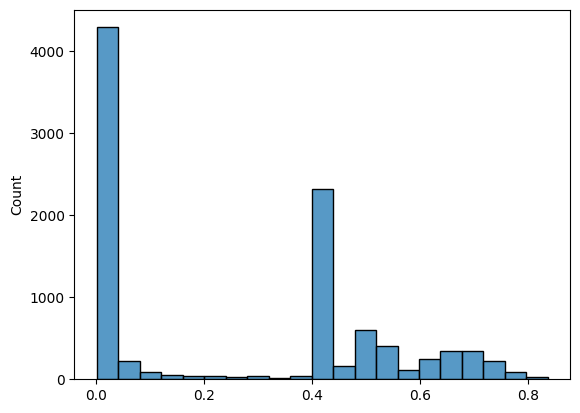

In [9]:
sns.histplot(probs)

<Axes: ylabel='Count'>

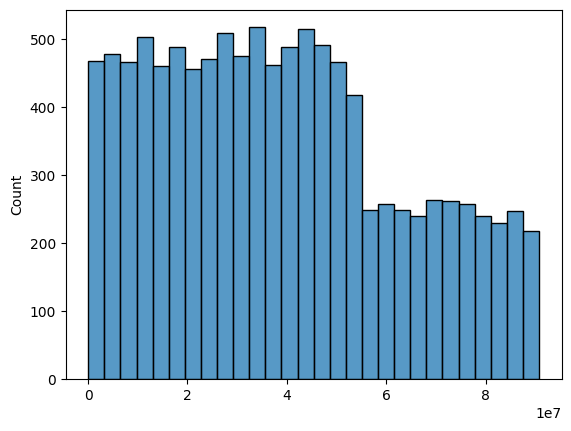

In [10]:
sns.histplot(np.concatenate(positions)[:, 0].astype('int')) # log_scale=True)

In [11]:
high_prob_positions = [pos for i, pos in enumerate(positions) if i in np.where(np.array(probs) > 0.50)[0].tolist()]
low_prob_positions = [pos for i, pos in enumerate(positions) if i in np.where(np.array(probs) <= 0.50)[0].tolist()]

<Axes: ylabel='Count'>

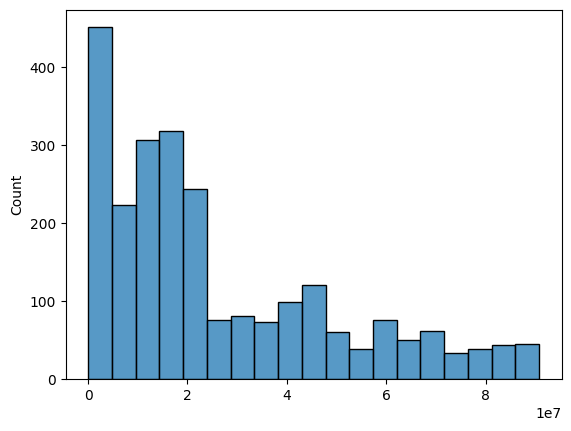

In [12]:
sns.histplot(np.concatenate(high_prob_positions)[:, 0].astype('int'))
            #  , log_scale=True)

<Axes: ylabel='Count'>

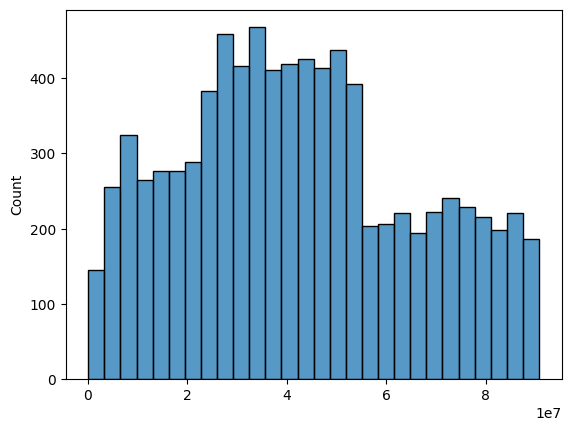

In [13]:
sns.histplot(np.concatenate(low_prob_positions)[:, 0].astype('int'))
# log_scale=True)

In [14]:
np.median(np.concatenate(low_prob_positions)[:, 0].astype('int'))

40605912.0

In [15]:
np.median(np.concatenate(high_prob_positions)[:, 0].astype('int'))

17837661.5

## Human

In [16]:
labels_human_test = pd.read_csv("~/chepurova/human_data/test.csv")

In [17]:
positions = []
probs = []

for sample_id, label in test_sample2labels.items():
    
    if sample_id in list(labels_human_test['sample']) and label == 0:
        
        samples_array = np.array(test_sample2chromosomes[sample_id]).reshape(-1, 16, 3)

        for i, sampled_chr in enumerate(samples_array):
            y_chr_positions = sampled_chr[np.char.find(sampled_chr[:, 0], "Y") >= 0][:, 1:]
            if len(y_chr_positions) > 0:
                positions.append(y_chr_positions)
                probs.append(test_sample2probs[sample_id][i].item())

In [18]:
len(probs)

3564

<Axes: ylabel='Count'>

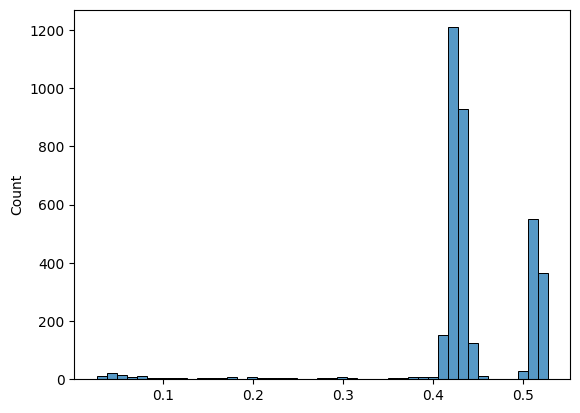

In [19]:
sns.histplot(probs)

In [25]:
positions

[array([['36848799', '36851871']], dtype='<U21'),
 array([['29804937', '29808009']], dtype='<U21'),
 array([['2273328', '2276400']], dtype='<U21'),
 array([['29426291', '29429363']], dtype='<U21'),
 array([['42475772', '42478844']], dtype='<U21'),
 array([['3185495', '3188567']], dtype='<U21'),
 array([['19208023', '19211095']], dtype='<U21'),
 array([['35289945', '35293017']], dtype='<U21'),
 array([['48789755', '48792827']], dtype='<U21'),
 array([['7037171', '7040243']], dtype='<U21'),
 array([['32815007', '32818079']], dtype='<U21'),
 array([['7010068', '7013140']], dtype='<U21'),
 array([['9969214', '9972286']], dtype='<U21'),
 array([['32540644', '32543716']], dtype='<U21'),
 array([['201493', '204565']], dtype='<U21'),
 array([['6731379', '6734451']], dtype='<U21'),
 array([['22956533', '22959605']], dtype='<U21'),
 array([['3772131', '3775203'],
        ['181320', '184392']], dtype='<U21'),
 array([['50965309', '50968381'],
        ['51673421', '51676493']], dtype='<U21'),
 arr

In [35]:
filtered_positions = np.concatenate(positions)[:, 0].astype('int')
filtered_positions = filtered_positions[filtered_positions < 1000000]
filtered_positions.shape

(57,)

<Axes: ylabel='Count'>

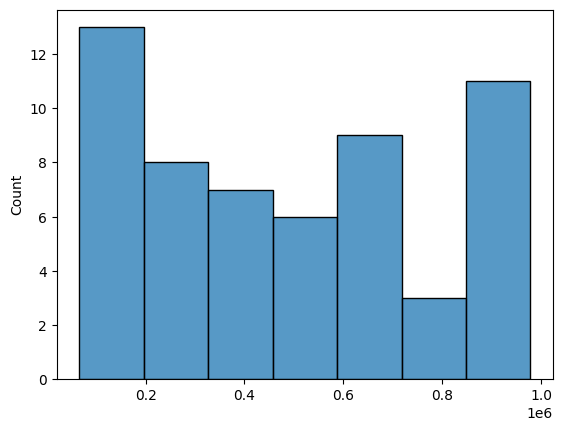

In [36]:
sns.histplot(filtered_positions)

<Axes: ylabel='Count'>

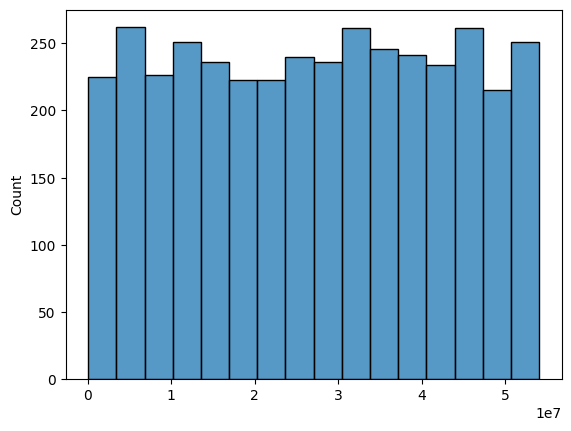

In [ ]:
sns.histplot(np.concatenate(positions)[:, 0].astype('int'))
# log_scale=True)

<Axes: >

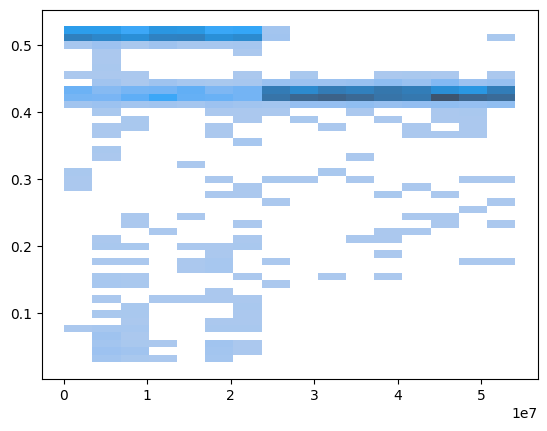

In [21]:
filtered_positions  = [int(pos[0][0]) for i, pos in enumerate(positions)]
sns.histplot(x=filtered_positions, y=probs)

<Axes: >

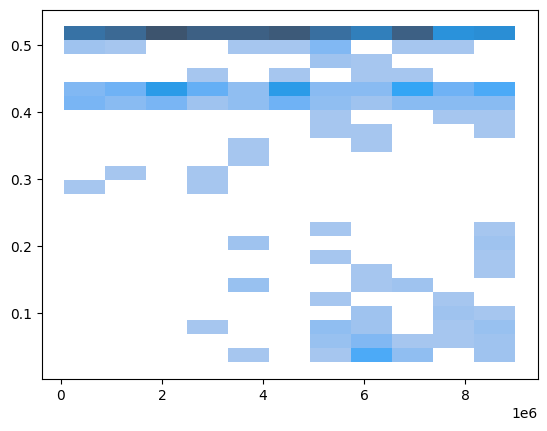

In [22]:
filtered_positions = np.array(filtered_positions)
filtered_probs = np.array(probs)[filtered_positions < 9e6]
filtered_positions = filtered_positions[filtered_positions < 9e6]
sns.histplot(x=filtered_positions, y=filtered_probs)

In [23]:
high_prob_positions = [pos for i, pos in enumerate(positions) if i in np.where(np.array(probs) > 0.50)[0].tolist()]
low_prob_positions = [pos for i, pos in enumerate(positions) if i in np.where(np.array(probs) <= 0.50)[0].tolist()]

<Axes: ylabel='Count'>

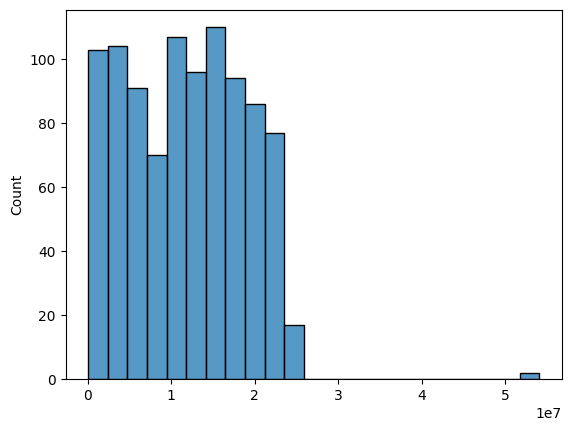

In [24]:
sns.histplot(np.concatenate(high_prob_positions)[:, 0].astype('int'))
# log_scale=True)

<Axes: ylabel='Count'>

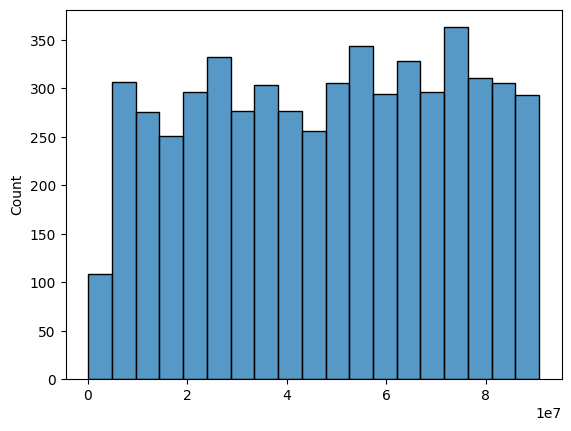

In [33]:
sns.histplot(np.concatenate(low_prob_positions)[:, 0].astype('int'))
# log_scale=True)

## Mice

In [34]:
labels_mouse_test = pd.read_csv("~/chepurova/mouse_data/test.csv")
labels_mouse_test.head()

,Unnamed: 0,strain_name,full_strain_name,gender,approximate sequence fold-coverage of the genome
0,0,C57BR_cdJ,(C57BR/cdJ),M,51
1,1,KK_HiJ,(KK/HiJ),M,55
2,2,PWK_PhJ,(PWK/PhJ),F,53
3,3,C3H_HeJ,(C3H/HeJ),F,63
4,4,SEA_GnJ,(SEA/GnJ),M,49


In [35]:
positions = []
probs = []

for sample_id, label in test_sample2labels.items():
    
    if sample_id in list(labels_mouse_test['strain_name']) and label == 0:
        
        samples_array = np.array(test_sample2chromosomes[sample_id]).reshape(-1, 16, 3)

        for i, sampled_chr in enumerate(samples_array):
            y_chr_positions = sampled_chr[np.char.find(sampled_chr[:, 0], "Y") >= 0][:, 1:]
            if len(y_chr_positions) > 0:
                positions.append(y_chr_positions)
                probs.append(test_sample2probs[sample_id][i].item())

In [36]:
len(probs)

6170

<Axes: ylabel='Count'>

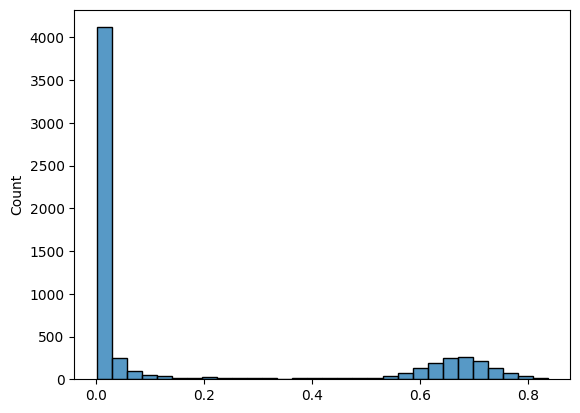

In [37]:
sns.histplot(probs)

<Axes: ylabel='Count'>

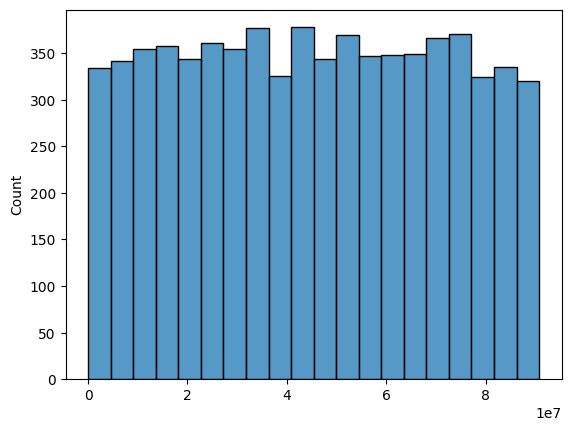

In [39]:
sns.histplot(np.concatenate(positions)[:, 0].astype('int'))
# log_scale=True)

In [40]:
high_prob_positions = [pos for i, pos in enumerate(positions) if i in np.where(np.array(probs) > 0.50)[0].tolist()]
low_prob_positions = [pos for i, pos in enumerate(positions) if i in np.where(np.array(probs) <= 0.50)[0].tolist()]

<Axes: >

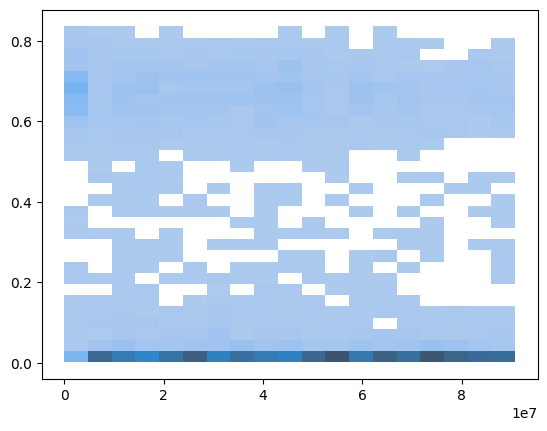

In [41]:
filtered_positions  = [int(pos[0][0]) for i, pos in enumerate(positions)]
sns.histplot(x=filtered_positions, y=probs)

<Axes: ylabel='Count'>

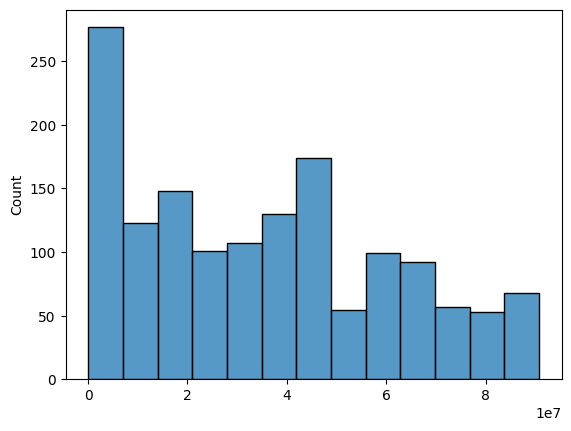

In [43]:
sns.histplot(np.concatenate(high_prob_positions)[:, 0].astype('int'))
            #   log_scale=True)

<Axes: ylabel='Count'>

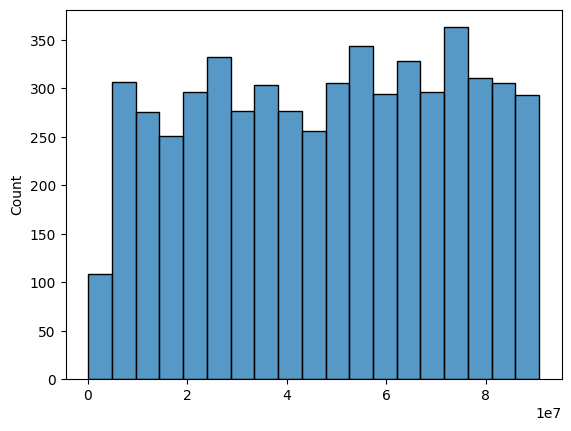

In [44]:
sns.histplot(np.concatenate(low_prob_positions)[:, 0].astype('int'))